# Electricity Theft Detection Project
### Section 1: Imports & Configuration

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
print('Setup complete ')

Setup complete 


In [28]:
# Global Settings
SEED = 42
DATA_PATH = 'Dataset/electricity_theft_dataset.csv'

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)
print(f'Configuration ready (Seed: {SEED})')

Configuration ready (Seed: 42)


### Section 2: Load & Inspect Dataset

In [29]:
# 1. Load data
df = pd.read_csv(DATA_PATH)
print(f'Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns')

# 2. Fast check
df.head()

Dataset Loaded: 5000 rows, 10 columns


,Timestamp,Voltage_V,Current_A,Power_W,Power_Factor,Season,Time_of_Day,Delta_I,Anomaly_Duration_min,Label
0,2024-01-01 00:00:00,233.675,1.503,321.618,0.8398,Winter,Night,0.051,0,Normal
1,2024-01-01 00:30:00,242.725,1.081,230.333,0.8800,Winter,Night,0.299,0,Normal
2,2024-01-01 01:00:00,229.085,1.799,397.845,0.8979,Winter,Night,0.372,0,Normal
3,2024-01-01 01:30:00,194.329,2.120,266.701,0.9397,Winter,Night,0.265,0,Normal
4,2024-01-01 02:00:00,216.927,1.755,293.586,0.8188,Winter,Night,0.017,87,Normal


In [30]:
# 3. Check for Nulls & Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             5000 non-null   object 
 1   Voltage_V             5000 non-null   float64
 2   Current_A             5000 non-null   float64
 3   Power_W               5000 non-null   float64
 4   Power_Factor          5000 non-null   float64
 5   Season                5000 non-null   object 
 6   Time_of_Day           5000 non-null   object 
 7   Delta_I               5000 non-null   float64
 8   Anomaly_Duration_min  5000 non-null   int64  
 9   Label                 5000 non-null   object 
dtypes: float64(5), int64(1), object(4)
memory usage: 390.8+ KB


In [31]:
# 4. Target class balance (Normal vs Abnormal)
print('Class Distribution:')
print(df['Label'].value_counts())

print('\nIn Percentage:')
print(df['Label'].value_counts(normalize=True) * 100)

Class Distribution:
Label
Normal      4250
Abnormal     750
Name: count, dtype: int64

In Percentage:
Label
Normal      85.0
Abnormal    15.0
Name: proportion, dtype: float64


### Section 3: Exploratory Data Analysis (EDA)
Detailed visual analysis of electricity usage patterns and theft signatures.

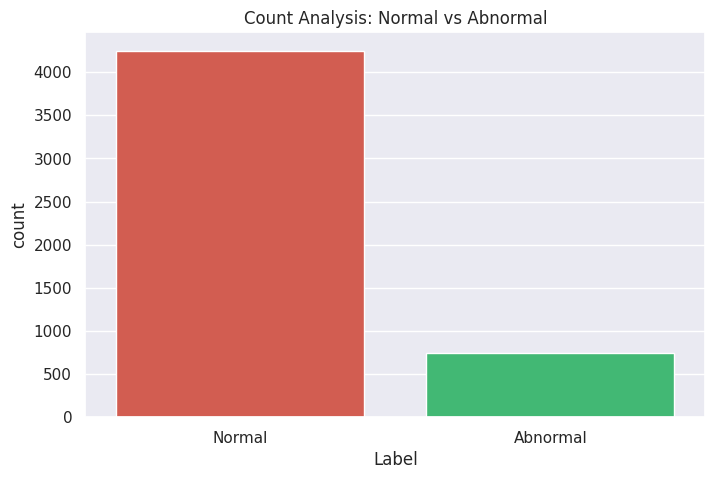

In [32]:
# 1. Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Label', palette=['#e74c3c', '#2ecc71'])
plt.title('Count Analysis: Normal vs Abnormal')
plt.show()

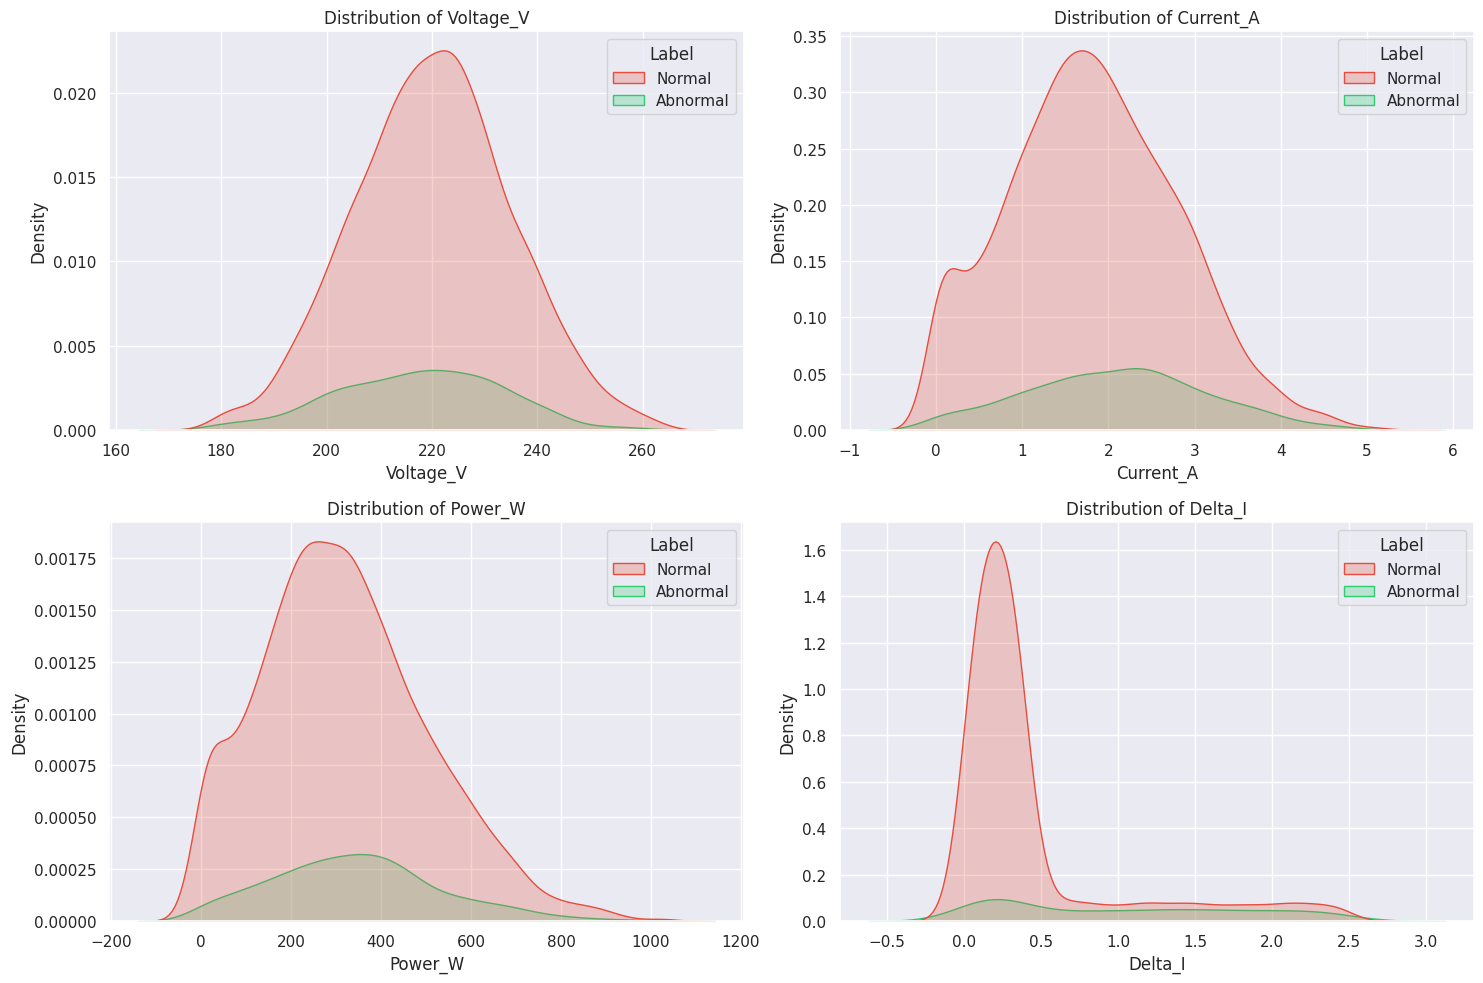

In [33]:
# 2. Feature Distributions (KDE plots)
cols = ['Voltage_V', 'Current_A', 'Power_W', 'Delta_I']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.kdeplot(data=df, x=col, hue='Label', fill=True, ax=axes[i], palette=['#e74c3c', '#2ecc71'])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

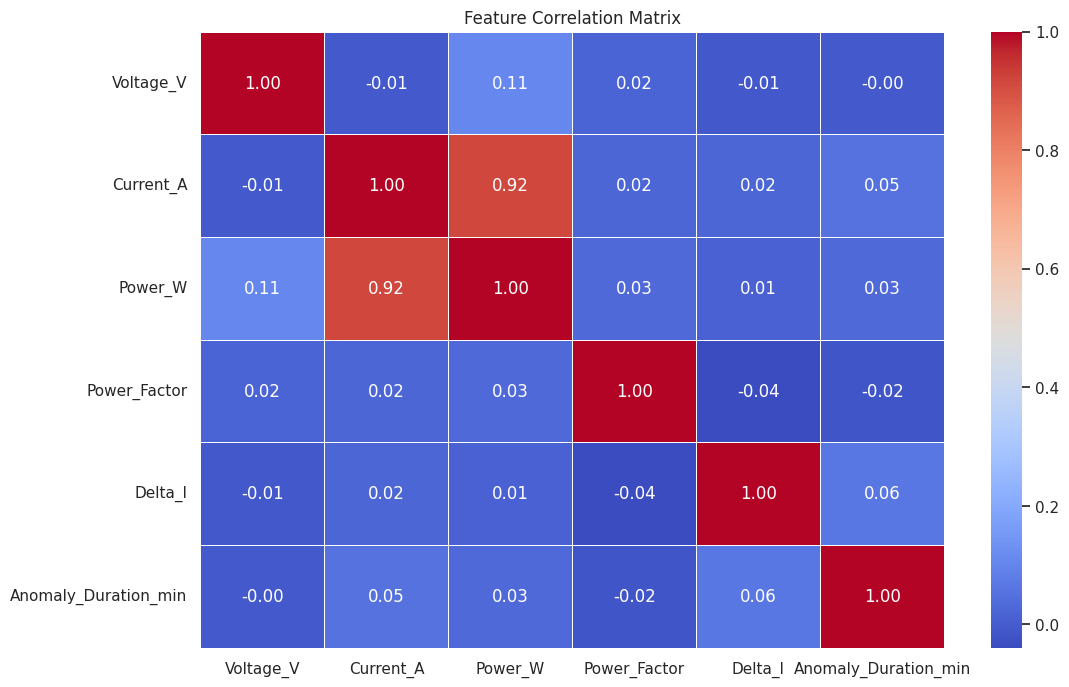

In [34]:
# 3. Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

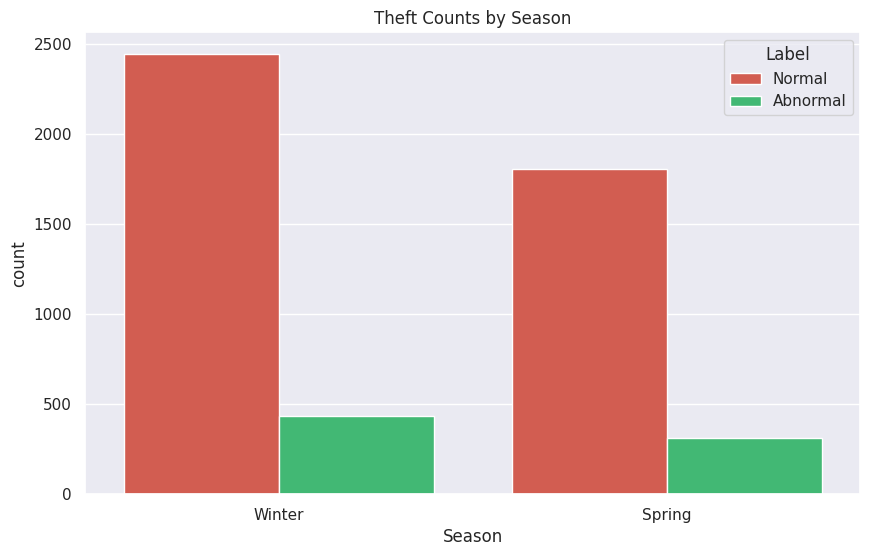

In [35]:
# 5. Season vs Theft
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Season', hue='Label', palette=['#e74c3c', '#2ecc71'])
plt.title('Theft Counts by Season')
plt.show()

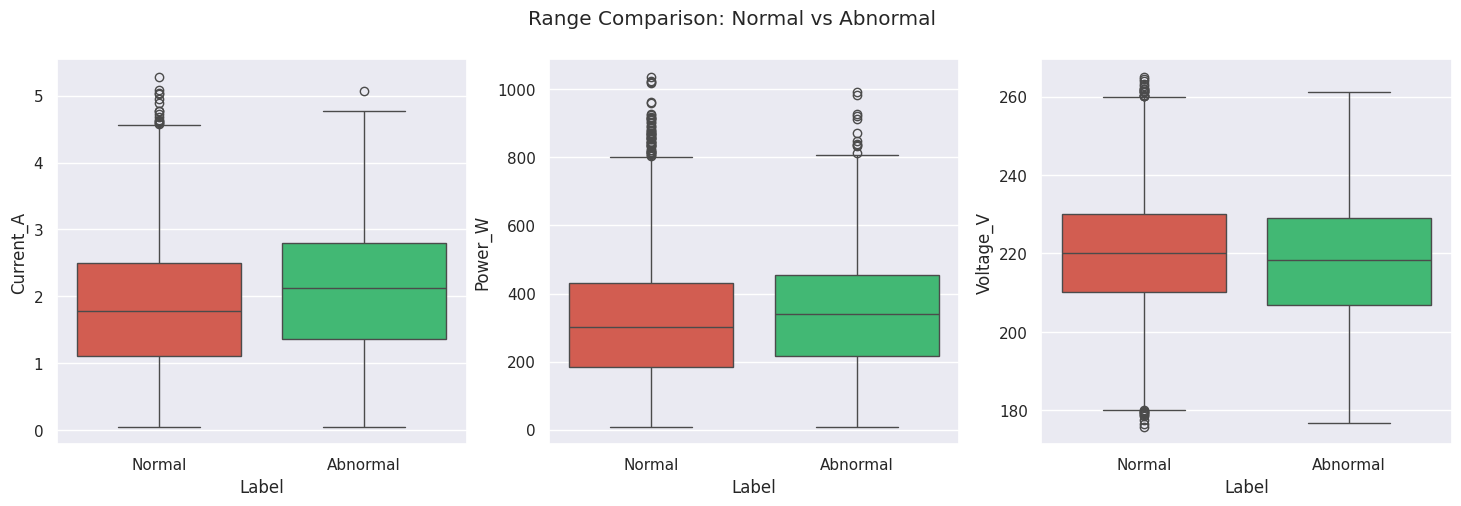

In [36]:
# 6. Box Plots for Key Features (Outlier/Range Analysis)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x='Label', y='Current_A', ax=axes[0], palette=['#e74c3c', '#2ecc71'])
sns.boxplot(data=df, x='Label', y='Power_W', ax=axes[1], palette=['#e74c3c', '#2ecc71'])
sns.boxplot(data=df, x='Label', y='Voltage_V', ax=axes[2], palette=['#e74c3c', '#2ecc71'])
plt.suptitle('Range Comparison: Normal vs Abnormal')
plt.show()

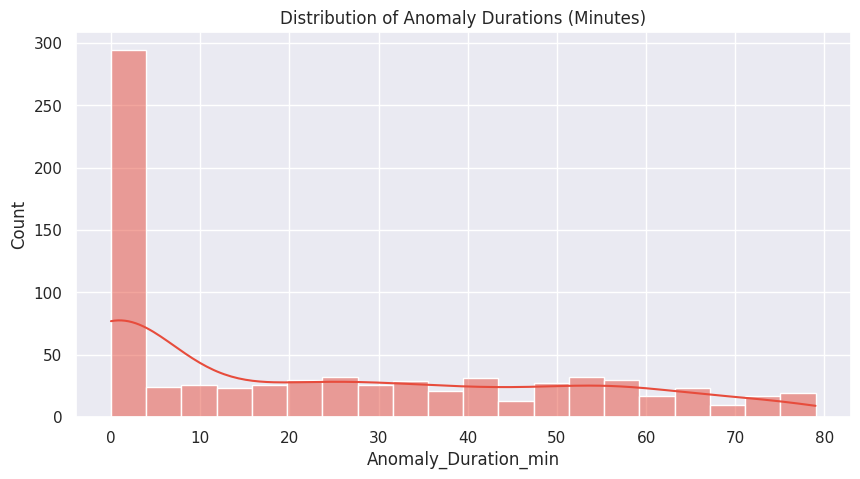

In [37]:
# 7. Anomaly Duration Analysis (Only for Abnormal cases)
plt.figure(figsize=(10, 5))
sns.histplot(df[df['Label']=='Abnormal']['Anomaly_Duration_min'], bins=20, color='#e74c3c', kde=True)
plt.title('Distribution of Anomaly Durations (Minutes)')
plt.show()

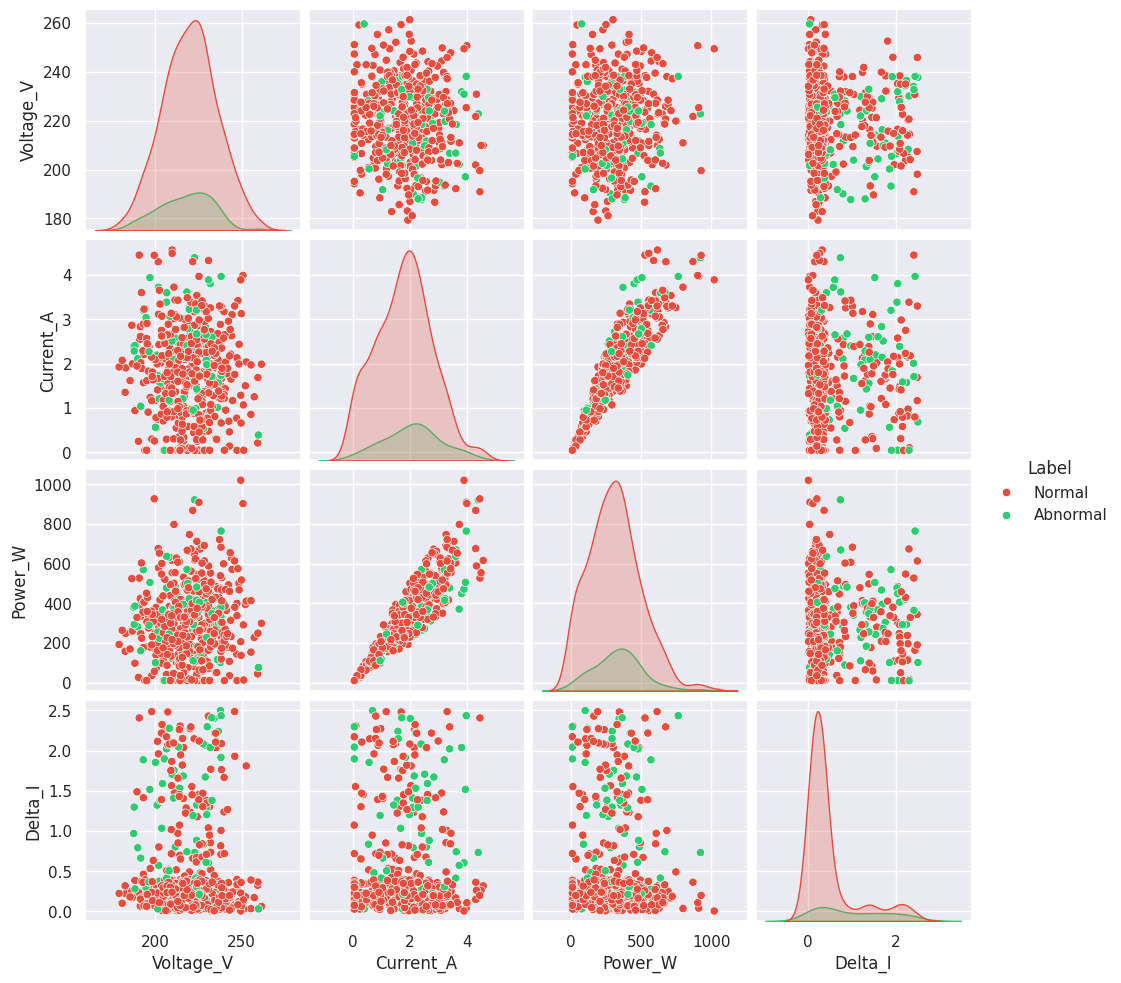

In [38]:
# 8. Pair Plot (Relationship Matrix - Sampling for speed)
sample_df = df.sample(500, random_state=SEED)
sns.pairplot(sample_df[['Voltage_V', 'Current_A', 'Power_W', 'Delta_I', 'Label']], hue='Label', palette=['#e74c3c', '#2ecc71'])
plt.show()

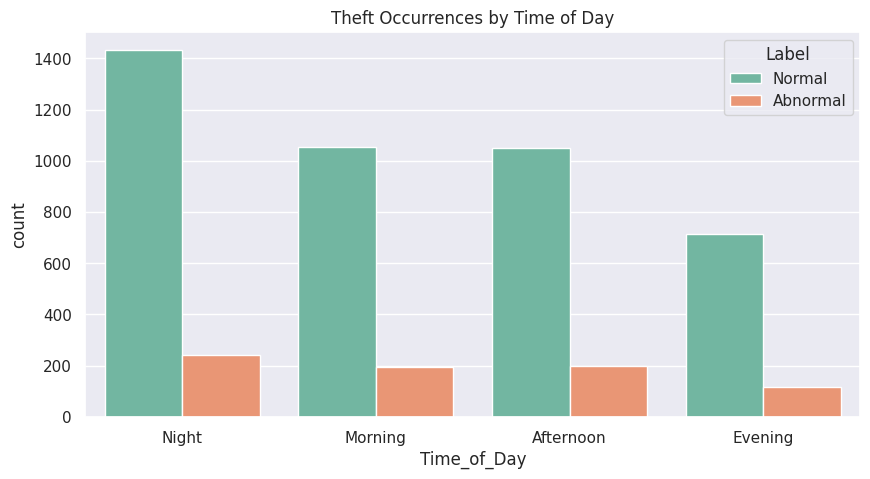

In [39]:
# 6. Time of Day vs Label Analysis
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Time_of_Day', hue='Label', palette='Set2')
plt.title('Theft Occurrences by Time of Day')
plt.show()

## Section 4: Data Preprocessing


In [40]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

print("--- Data Preprocessing Started ---")

# 1. Drop Timestamp (not useful for ML)
if 'Timestamp' in df.columns:
    df = df.drop(columns=['Timestamp'])
    print("Dropped: Timestamp")

# 2. Keep ALL features (Delta_I & Anomaly_Duration_min now have genuine overlap)
print(f"Features available: {list(df.columns)}")

# 3. Encode Categorical Features
le_season = LabelEncoder()
df['Season'] = le_season.fit_transform(df['Season'])
print("Season mapping:", dict(zip(le_season.classes_, le_season.transform(le_season.classes_))))

le_time = LabelEncoder()
df['Time_of_Day'] = le_time.fit_transform(df['Time_of_Day'])
print("Time_of_Day mapping:", dict(zip(le_time.classes_, le_time.transform(le_time.classes_))))

# 4. Map Label
if df['Label'].dtype == 'object':
    df['Label'] = df['Label'].map({'Normal': 0, 'Abnormal': 1})
    print("Mapped: Normal->0, Abnormal->1")

# 5. Separate Features and Target
X = df.drop(columns=['Label'])
y = df['Label']
print(f"Features used: {list(X.columns)}")

# 6. Train-Test Split (70/30 with stratify for proper evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y, shuffle=True
)
print(f"Split: Train={X_train.shape[0]}, Test={X_test.shape[0]}")
print(f"Train class dist: {y_train.value_counts().to_dict()}")
print(f"Test class dist:  {y_test.value_counts().to_dict()}")

# 7. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n Preprocessing Complete!")
print(f"Training shape: {X_train_scaled.shape}")
print(f"Testing shape: {X_test_scaled.shape}")


--- Data Preprocessing Started ---
Dropped: Timestamp
Features available: ['Voltage_V', 'Current_A', 'Power_W', 'Power_Factor', 'Season', 'Time_of_Day', 'Delta_I', 'Anomaly_Duration_min', 'Label']
Season mapping: {'Spring': np.int64(0), 'Winter': np.int64(1)}
Time_of_Day mapping: {'Afternoon': np.int64(0), 'Evening': np.int64(1), 'Morning': np.int64(2), 'Night': np.int64(3)}
Mapped: Normal->0, Abnormal->1
Features used: ['Voltage_V', 'Current_A', 'Power_W', 'Power_Factor', 'Season', 'Time_of_Day', 'Delta_I', 'Anomaly_Duration_min']
Split: Train=3500, Test=1500
Train class dist: {0: 2975, 1: 525}
Test class dist:  {0: 1275, 1: 225}

 Preprocessing Complete!
Training shape: (3500, 8)
Testing shape: (1500, 8)


## Section 4.1: SMOTE

In [41]:
from imblearn.over_sampling import SMOTE
import numpy as np

print("--- Balancing Training Data (SMOTE) ---")

# SMOTE apply karein taaki Abnormal cases badh jayein
smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training shape: {X_train_scaled.shape}")
print(f"Resampled training shape: {X_train_res.shape}")
print(f"Balanced class distribution: {dict(zip(*np.unique(y_train_res, return_counts=True)))}")


--- Balancing Training Data (SMOTE) ---
Original training shape: (3500, 8)
Resampled training shape: (5950, 8)
Balanced class distribution: {np.int64(0): np.int64(2975), np.int64(1): np.int64(2975)}


## Section 5: Model Training


In [42]:
# import time
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.model_selection import cross_val_score
# from sklearn.metrics import accuracy_score, classification_report

# print("--- Model Training Started ---\n")

# # Models with increased complexity for thorough training
# models = {
#     "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
#     "Random Forest": RandomForestClassifier(n_estimators=500, max_depth=10, random_state=SEED),
#     "Gradient Boosting": GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=SEED)
# }

# model_results = {}

# for name, model in models.items():
#     start_time = time.time()
    
#     # Step 1: 5-Fold Cross Validation on training data
#     print(f"{'='*50}")
#     print(f"{name}")
#     print(f"{'='*50}")
#     print(f"Running 5-Fold Cross Validation...")
#     cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
#     print(f"CV Scores: {cv_scores}")
#     print(f"CV Mean Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
#     # Step 2: Train on full training set
#     print(f"\nTraining on full training set...")
#     model.fit(X_train_scaled, y_train)
    
#     # Step 3: Predict on test set
#     y_pred = model.predict(X_test_scaled)
#     acc = accuracy_score(y_test, y_pred)
#     model_results[name] = {'accuracy': acc, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(), 'model': model}
    
#     elapsed = time.time() - start_time
    
#     print(f"\nTest Accuracy: {acc:.4f}")
#     print(f"Training Time: {elapsed:.2f} seconds")
#     print(f"\nClassification Report:")
#     print(classification_report(y_test, y_pred))

# # Summary Table
# print(f"\n{'='*60}")
# print(f"Model Comparison Summary")
# print(f"{'='*60}")
# print(f"{'Model':<25} {'Test Acc':>10} {'CV Mean':>10} {'CV Std':>10}")
# print(f"{'-'*55}")
# for name, res in model_results.items():
#     print(f"{name:<25} {res['accuracy']:>10.4f} {res['cv_mean']:>10.4f} {res['cv_std']:>10.4f}")

# print(f"\n Model Training Complete!")

import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report

print("--- Model Training Started (With Balanced Data) ---\n")

# Optimized models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=500, max_depth=12, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=SEED)
}

model_results = {}

for name, model in models.items():
    start_time = time.time()
    
    print(f"{'='*50}\n{name}\n{'='*50}")
    print(f"Running 5-Fold Cross Validation...")
    # Balanced data use kar rahe hain CV ke liye
    cv_scores = cross_val_score(model, X_train_res, y_train_res, cv=5, scoring='accuracy')
    print(f"CV Mean Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    print(f"\nTraining on balanced training set...")
    model.fit(X_train_res, y_train_res)
    
    # Prediction asli test set par hi hogi
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    model_results[name] = {'accuracy': acc, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(), 'model': model}
    
    print(f"Test Accuracy: {acc:.4f}\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal']))

print("\nModel Training Complete with SMOTE!")


--- Model Training Started (With Balanced Data) ---

Logistic Regression
Running 5-Fold Cross Validation...
CV Mean Accuracy: 0.7543 (+/- 0.0077)

Training on balanced training set...
Test Accuracy: 0.7807
Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.79      0.86      1275
    Abnormal       0.38      0.75      0.51       225

    accuracy                           0.78      1500
   macro avg       0.66      0.77      0.68      1500
weighted avg       0.86      0.78      0.81      1500

Random Forest
Running 5-Fold Cross Validation...
CV Mean Accuracy: 0.8901 (+/- 0.0164)

Training on balanced training set...
Test Accuracy: 0.8527
Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.88      0.91      1275
    Abnormal       0.51      0.69      0.58       225

    accuracy                           0.85      1500
   macro avg       0.72      0.79      0.75      1500
we

## Section 6: Model Evaluation & Results

In this section, we perform a comprehensive evaluation of all trained models using multiple metrics:
- **Classification Report** (Precision, Recall, F1-Score)
- **Confusion Matrix** heatmaps for each model
- **ROC Curves** with AUC scores (all models on one plot)
- **Model Comparison Table** for side-by-side analysis


In [43]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

print("=" * 60)
print("MODEL EVALUATION & RESULTS")
print("=" * 60)

# Store predictions and metrics for all models
predictions = {}
metrics_data = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    metrics_data.append({
        'Model': name,
        'Accuracy': round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall': round(rec * 100, 2),
        'F1-Score': round(f1 * 100, 2)
    })
    
    print(f"\n{'' * 40}")
    print(f" {name}")
    print(f"{'' * 40}")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal']))

print("\n Classification reports generated for all models.")


MODEL EVALUATION & RESULTS


 Logistic Regression

              precision    recall  f1-score   support

      Normal       0.95      0.79      0.86      1275
    Abnormal       0.38      0.75      0.51       225

    accuracy                           0.78      1500
   macro avg       0.66      0.77      0.68      1500
weighted avg       0.86      0.78      0.81      1500



 Random Forest

              precision    recall  f1-score   support

      Normal       0.94      0.88      0.91      1275
    Abnormal       0.51      0.69      0.58       225

    accuracy                           0.85      1500
   macro avg       0.72      0.79      0.75      1500
weighted avg       0.88      0.85      0.86      1500



 Gradient Boosting

              precision    recall  f1-score   support

      Normal       0.94      0.89      0.91      1275
    Abnormal       0.52      0.65      0.58       225

    accuracy                           0.86      1500
   macro avg       0.73      0.77    

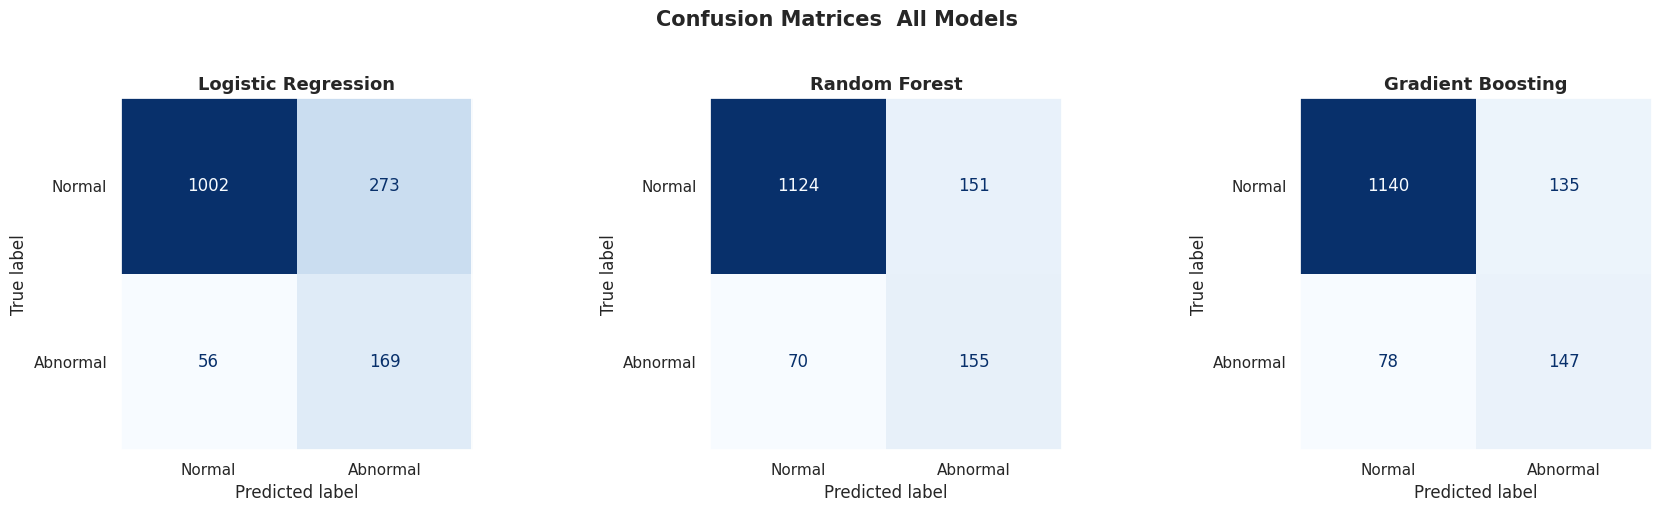


 Confusion matrices plotted for all models.


In [44]:
#  Confusion Matrix Heatmaps (side by side) 
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))
if len(models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Abnormal'])
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.grid(False)

plt.suptitle('Confusion Matrices  All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n Confusion matrices plotted for all models.")


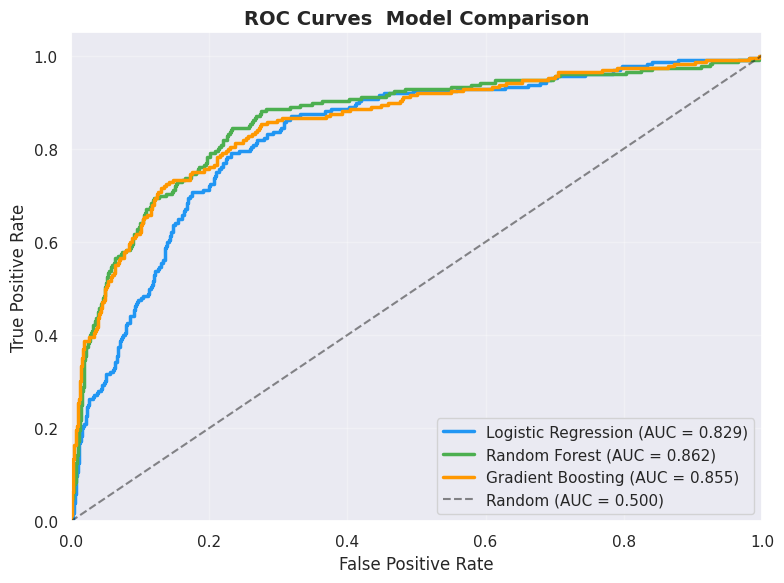


 ROC curves plotted with AUC scores.


In [45]:
#  ROC Curves (all models on one plot) 
plt.figure(figsize=(8, 6))

colors = ['#2196F3', '#4CAF50', '#FF9800']
for idx, (name, model) in enumerate(models.items()):
    if hasattr(model, 'predict_proba'):
        y_probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_probs = model.decision_function(X_test_scaled)
    
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colors[idx % len(colors)], lw=2.5,
             label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves  Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n ROC curves plotted with AUC scores.")



 MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression     78.07      38.24   75.11     50.67
Random Forest           85.27      50.65   68.89     58.38
Gradient Boosting       85.80      52.13   65.33     57.99

 Best Model: Random Forest
   Accuracy:  85.27%
   F1-Score:  58.38%


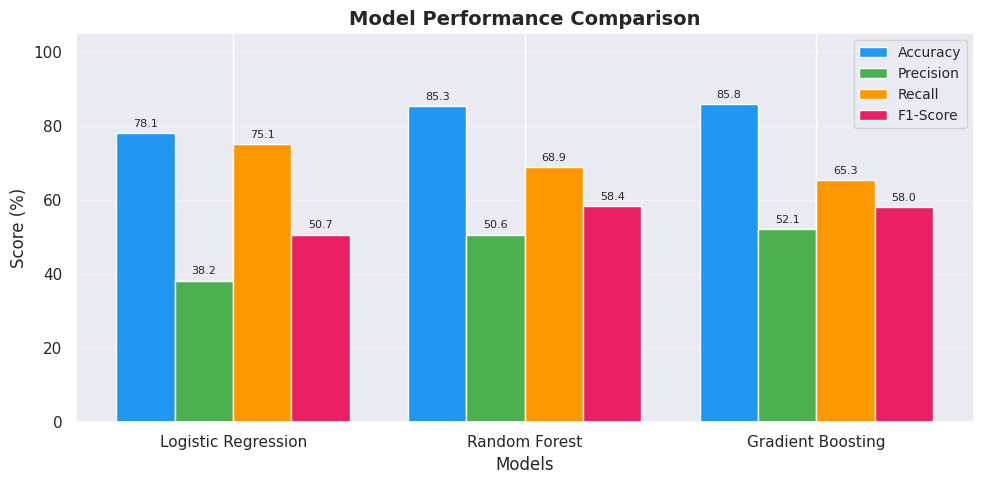


 Section 6 Complete  Random Forest is the recommended model.


In [46]:
#  Model Comparison Table 
comparison_df = pd.DataFrame(metrics_data)
comparison_df = comparison_df.set_index('Model')

print("\n" + "=" * 60)
print(" MODEL COMPARISON TABLE")
print("=" * 60)
print(comparison_df.to_string())

# Highlight best model
best_model = comparison_df['F1-Score'].idxmax()
best_f1 = comparison_df.loc[best_model, 'F1-Score']
best_acc = comparison_df.loc[best_model, 'Accuracy']

print(f"\n Best Model: {best_model}")
print(f"   Accuracy:  {best_acc}%")
print(f"   F1-Score:  {best_f1}%")

# Visual comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.2

bars1 = ax.bar(x - 1.5*width, comparison_df['Accuracy'], width, label='Accuracy', color='#2196F3')
bars2 = ax.bar(x - 0.5*width, comparison_df['Precision'], width, label='Precision', color='#4CAF50')
bars3 = ax.bar(x + 0.5*width, comparison_df['Recall'], width, label='Recall', color='#FF9800')
bars4 = ax.bar(x + 1.5*width, comparison_df['F1-Score'], width, label='F1-Score', color='#E91E63')

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\n Section 6 Complete  {best_model} is the recommended model.")


In [47]:
# SMOTE ke baad ka ratio check karne ke liye
import pandas as pd
print("After SMOTE Class Distribution:")
print(pd.Series(y_train_res).value_counts())

print("\nPercentage:")
print(pd.Series(y_train_res).value_counts(normalize=True) * 100)


After SMOTE Class Distribution:
Label
0    2975
1    2975
Name: count, dtype: int64

Percentage:
Label
0    50.0
1    50.0
Name: proportion, dtype: float64


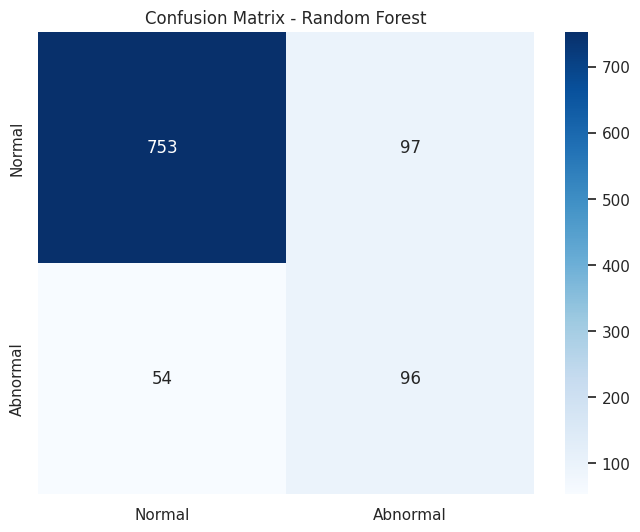

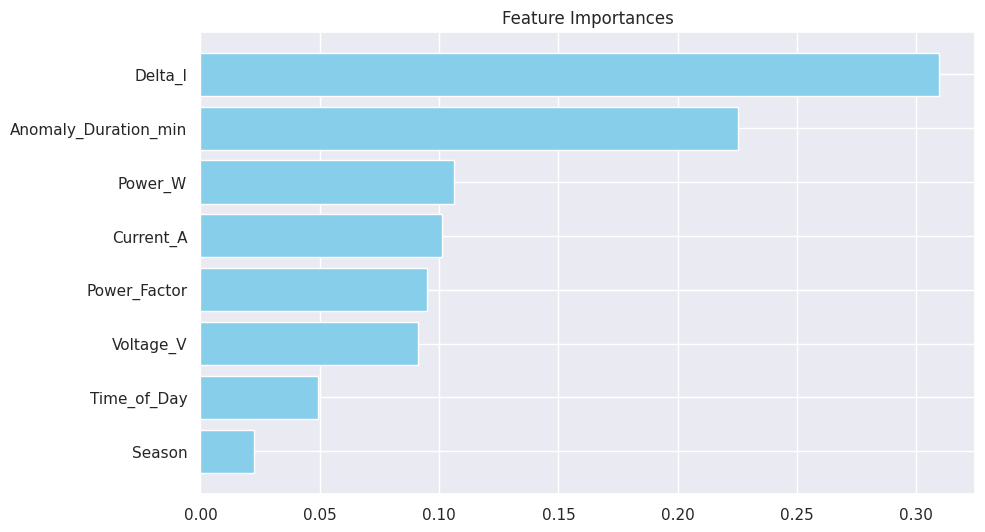

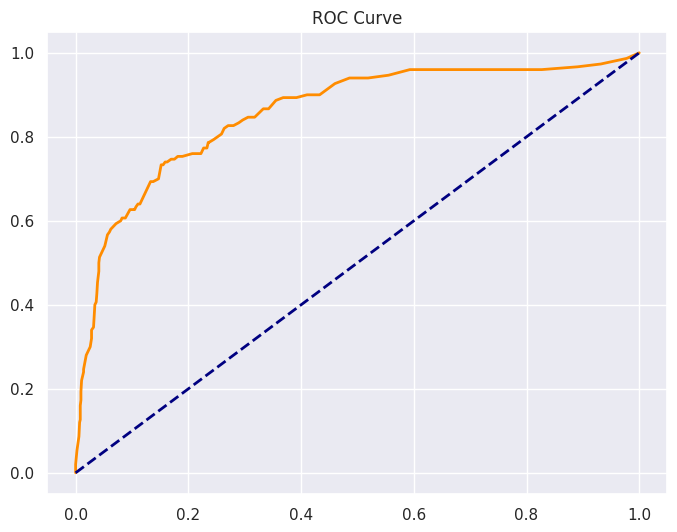

Done! Ab images documentation mein dikhne lagengi.


In [49]:
# --- Self-Contained Cell to Save All Images ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE

# 1. Data Load aur Preprocess (Just in case memory clear ho gayi ho)
df_temp = pd.read_csv('Dataset/electricity_theft_dataset.csv')
le_temp = LabelEncoder()
df_temp['Season'] = le_temp.fit_transform(df_temp['Season'])
df_temp['Time_of_Day'] = le_temp.fit_transform(df_temp['Time_of_Day'])
df_temp['Label'] = df_temp['Label'].map({'Normal': 0, 'Abnormal': 1})

X_temp = df_temp.drop(['Timestamp', 'Label'], axis=1)
y_temp = df_temp['Label']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

# 2. SMOTE aur Model Training
smote_t = SMOTE(random_state=42)
X_res_t, y_res_t = smote_t.fit_resample(X_train_t, y_train_t)

rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_res_t, y_res_t)

# 3. Predictions
y_pred_t = rf_final.predict(X_test_t)
y_probs_t = rf_final.predict_proba(X_test_t)[:, 1]

# --- SAVE IMAGES ---

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_t, y_pred_t)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.title('Confusion Matrix - Random Forest')
plt.savefig('confusion_matrix.png')
plt.show()

# Feature Importance
plt.figure(figsize=(10, 6))
importances = rf_final.feature_importances_
indices = np.argsort(importances)
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [X_temp.columns[i] for i in indices])
plt.title('Feature Importances')
plt.savefig('feature_importance.png')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_t, y_probs_t)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC Curve')
plt.savefig('roc_curve.png')
plt.show()

print("Done! Ab images documentation mein dikhne lagengi.")
